In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm
import numpy as np
import seaborn as sns

data_path = "../emissions"
training_phase_data_raw = pd.read_csv(f"{data_path}/run_params_training_phase.csv")
prompting_phase_data_raw = pd.read_csv(f"{data_path}/run_params_prompting_phase.csv")
emissions_raw = pd.read_csv(f"{data_path}/emissions.csv")

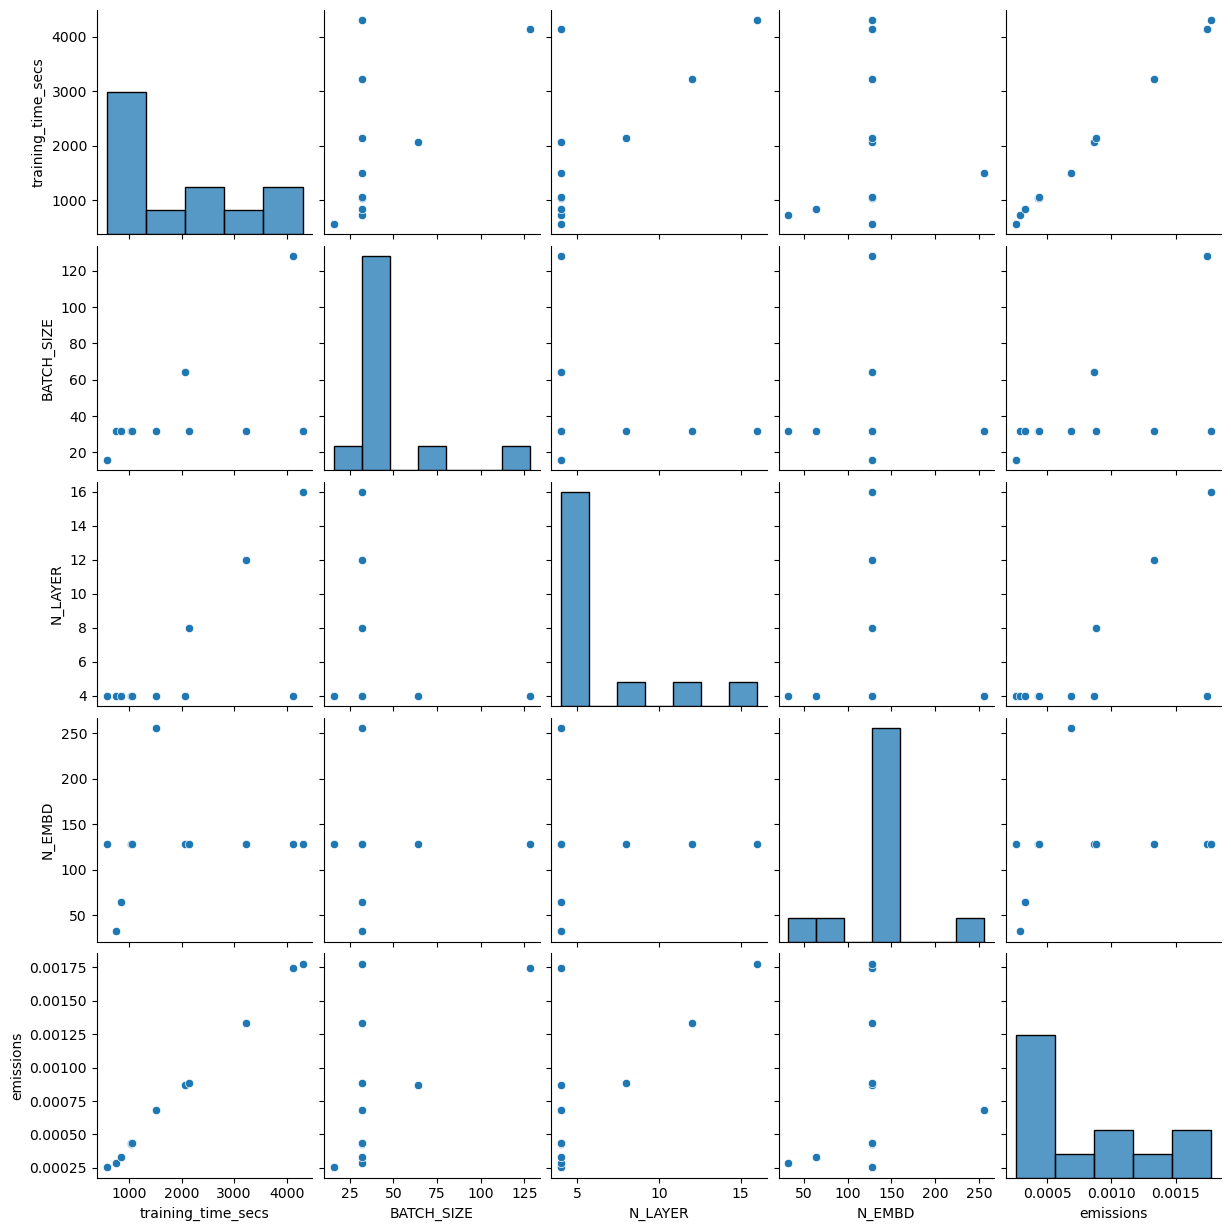

In [39]:
training_phase_data = training_phase_data_raw[["training_time_secs","BATCH_SIZE", "N_LAYER", "N_EMBD" ,"emissions"]]

sns.pairplot(data=training_phase_data)

In [47]:
lm_train = smf.ols("emissions ~ BATCH_SIZE + N_LAYER + N_EMBD", data=training_phase_data).fit()
print(lm_train.summary())

                            OLS Regression Results                            
Dep. Variable:              emissions   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                     6567.
Date:                Sat, 18 Apr 2026   Prob (F-statistic):           6.68e-14
Time:                        21:13:41   Log-Likelihood:                 120.40
No. Observations:                  12   AIC:                            -232.8
Df Residuals:                       8   BIC:                            -230.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0007   1.33e-05    -49.326      0.0

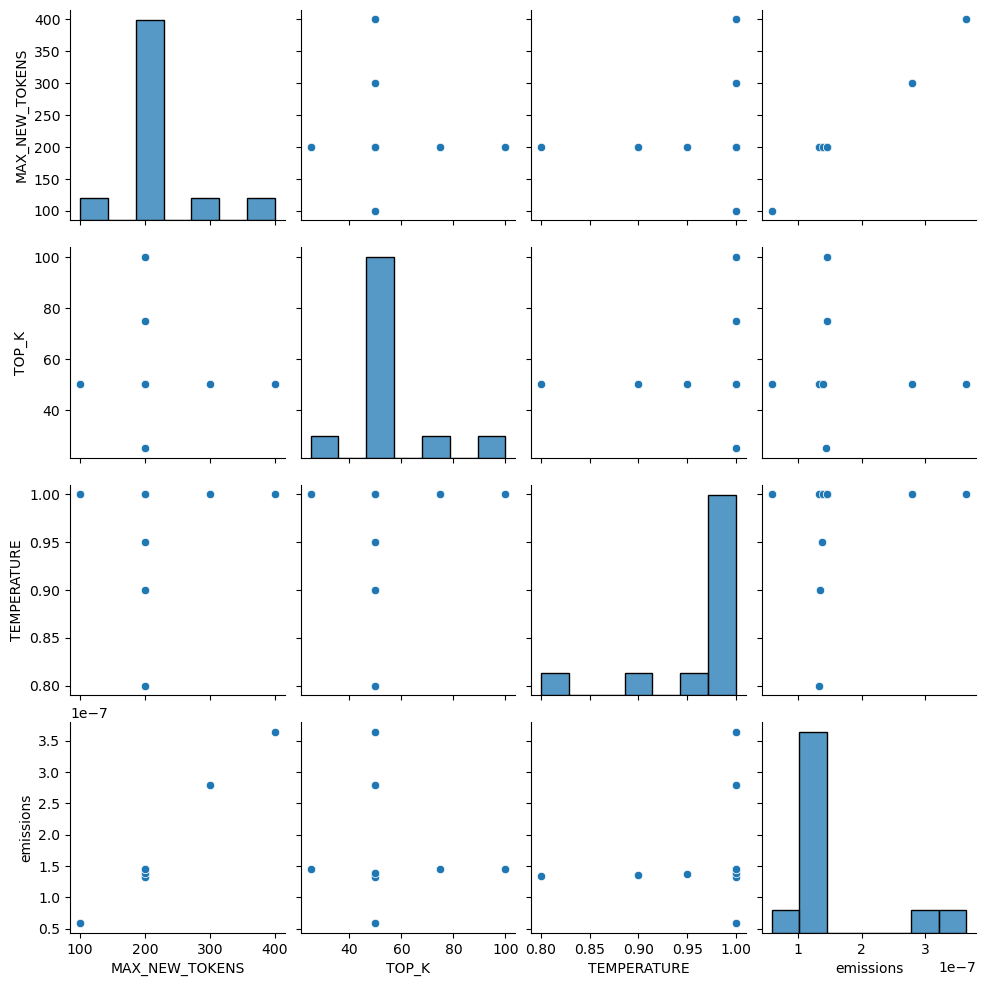

In [44]:
prompting_phase_data = prompting_phase_data_raw[["MAX_NEW_TOKENS", "TOP_K", "TEMPERATURE" ,"emissions"]]

sns.pairplot(data=prompting_phase_data)

In [46]:
lm_prompt = smf.ols("emissions ~ MAX_NEW_TOKENS + TOP_K + TEMPERATURE", data=prompting_phase_data).fit()
print(lm_prompt.summary())

                            OLS Regression Results                            
Dep. Variable:              emissions   R-squared:                       0.980
Model:                            OLS   Adj. R-squared:                  0.973
Method:                 Least Squares   F-statistic:                     132.4
Date:                Sat, 18 Apr 2026   Prob (F-statistic):           3.71e-07
Time:                        21:13:31   Log-Likelihood:                 203.15
No. Observations:                  12   AIC:                            -398.3
Df Residuals:                       8   BIC:                            -396.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept      -1.546e-07   6.26e-08     -2.